In [1]:
import os
import random
import copy
import time
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ============================================================
# CONFIGURATION
# ============================================================

SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 14
NUM_WORKERS = 2

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("=" * 70)
print("EXPERIMENT SETUP")
print("=" * 70)

print("PyTorch       :", torch.__version__)
print("CUDA          :", torch.cuda.is_available())
print("Device        :", DEVICE)

if torch.cuda.is_available():
    print("GPU           :", torch.cuda.get_device_name(0))

print("Seed          :", SEED)
print("Input size    :", IMG_SIZE)
print("Batch size    :", BATCH_SIZE)

EXPERIMENT SETUP
PyTorch       : 2.10.0+cu128
CUDA          : True
Device        : cuda
GPU           : Tesla T4
Seed          : 42
Input size    : 224
Batch size    : 32


In [2]:
# ============================================================
# DATASET PATH DETECTION
# ============================================================

import os

IMAGE_EXTENSIONS = (
    ".jpg", ".jpeg", ".png",
    ".bmp", ".tif", ".tiff", ".webp"
)

def count_images_recursive(folder):
    total = 0

    for root, dirs, files in os.walk(folder):
        total += sum(
            1 for file in files
            if file.lower().endswith(IMAGE_EXTENSIONS)
        )

    return total


def count_direct_folders(folder):
    try:
        return len([
            d for d in os.listdir(folder)
            if os.path.isdir(os.path.join(folder, d))
        ])
    except:
        return 0


TRAIN_DIR = None
VAL_DIR = None
TEST_DIR = None


for root, dirs, files in os.walk("/kaggle/input"):

    if count_direct_folders(root) != 14:
        continue

    n_images = count_images_recursive(root)

    if n_images == 744:
        TRAIN_DIR = root

    elif n_images == 161:
        VAL_DIR = root

    elif n_images == 157:
        TEST_DIR = root


if TRAIN_DIR is None:
    raise RuntimeError("Train split with 744 images not found.")

if VAL_DIR is None:
    raise RuntimeError("Validation split with 161 images not found.")

if TEST_DIR is None:
    raise RuntimeError("Test split with 157 images not found.")


DATASET_ROOT = os.path.commonpath([
    TRAIN_DIR,
    VAL_DIR,
    TEST_DIR
])


print("=" * 70)
print("DATASET PATHS")
print("=" * 70)

print("Dataset root :", DATASET_ROOT)
print("Train        :", TRAIN_DIR)
print("Validation   :", VAL_DIR)
print("Test         :", TEST_DIR)

print("\n✅ Dataset located successfully.")

DATASET PATHS
Dataset root : /kaggle/input/datasets/srabondcosta/aqua-plant-final-dataset/AquPlantDS_FINAL
Train        : /kaggle/input/datasets/srabondcosta/aqua-plant-final-dataset/AquPlantDS_FINAL/Train
Validation   : /kaggle/input/datasets/srabondcosta/aqua-plant-final-dataset/AquPlantDS_FINAL/Validation
Test         : /kaggle/input/datasets/srabondcosta/aqua-plant-final-dataset/AquPlantDS_FINAL/Test

✅ Dataset located successfully.


In [3]:
IMAGE_EXTENSIONS = (
    ".jpg", ".jpeg", ".png",
    ".bmp", ".tif", ".tiff",
    ".webp"
)


def count_images(folder):

    total = 0

    for root, dirs, files in os.walk(folder):

        total += sum(
            1
            for file in files
            if file.lower().endswith(IMAGE_EXTENSIONS)
        )

    return total


train_count = count_images(TRAIN_DIR)
val_count = count_images(VAL_DIR)
test_count = count_images(TEST_DIR)

train_classes = sorted([
    d for d in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, d))
])

val_classes = sorted([
    d for d in os.listdir(VAL_DIR)
    if os.path.isdir(os.path.join(VAL_DIR, d))
])

test_classes = sorted([
    d for d in os.listdir(TEST_DIR)
    if os.path.isdir(os.path.join(TEST_DIR, d))
])


print("=" * 70)
print("DATASET VERIFICATION")
print("=" * 70)

print("Train      :", train_count)
print("Validation :", val_count)
print("Test       :", test_count)
print("Total      :", train_count + val_count + test_count)
print("Classes    :", len(train_classes))


assert train_count == 744
assert val_count == 161
assert test_count == 157

assert train_count + val_count + test_count == 1062

assert train_classes == val_classes == test_classes

assert len(train_classes) == 14


print("\n✅ Correct dataset confirmed.")
print("✅ Train = 744")
print("✅ Validation = 161")
print("✅ Test = 157")
print("✅ Classes = 14")

DATASET VERIFICATION
Train      : 744
Validation : 161
Test       : 157
Total      : 1062
Classes    : 14

✅ Correct dataset confirmed.
✅ Train = 744
✅ Validation = 161
✅ Test = 157
✅ Classes = 14


In [4]:
IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225
]


# ============================================================
# TRAIN TRANSFORM
# ============================================================

train_transform = transforms.Compose([

    transforms.RandomRotation(
        degrees=10,
        fill=(124, 116, 104)
    ),

    transforms.RandomResizedCrop(
        IMG_SIZE,
        scale=(0.85, 1.0)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


# ============================================================
# VALIDATION TRANSFORM
# ============================================================

val_transform = transforms.Compose([

    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


print("✅ Standardized preprocessing created.")

✅ Standardized preprocessing created.


In [5]:
train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    VAL_DIR,
    transform=val_transform
)


assert (
    train_dataset.class_to_idx
    ==
    val_dataset.class_to_idx
)


train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=True
)


val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=True
)


print("=" * 70)
print("DATALOADER VERIFICATION")
print("=" * 70)

print("Train      :", len(train_dataset))
print("Validation :", len(val_dataset))

print("Train batches :", len(train_loader))
print("Val batches   :", len(val_loader))

print("\nClass mapping:")

for cls, idx in train_dataset.class_to_idx.items():
    print(idx, "->", cls)


print("\n🔒 TEST SET HAS NOT BEEN LOADED.")

DATALOADER VERIFICATION
Train      : 744
Validation : 161
Train batches : 24
Val batches   : 6

Class mapping:
0 -> Class_10_lippia_alba
1 -> Class_11_marsilea_minuta
2 -> Class_12_duck_weeds
3 -> Class_13_topapana
4 -> Class_14_kachuripana
5 -> Class_1_water_iris
6 -> Class_2_pistia_stratiotes
7 -> Class_3_lily_leaf
8 -> Class_4_lotus-leaf
9 -> Class_5_water_popy
10 -> Class_6_salvania
11 -> Class_7_chinese_water_spinach
12 -> Class_8_water_plantain
13 -> Class_9_mexican_sword_lily

🔒 TEST SET HAS NOT BEEN LOADED.


In [6]:
# ============================================================
# BATCH VERIFICATION
# ============================================================

images, labels = next(iter(train_loader))

print("=" * 70)
print("BATCH VERIFICATION")
print("=" * 70)

print("Image batch shape :", images.shape)
print("Label batch shape :", labels.shape)

print("\nExpected image shape:")
print("[32, 3, 224, 224]")

print("\n✅ Training batch successfully loaded.")

BATCH VERIFICATION
Image batch shape : torch.Size([32, 3, 224, 224])
Label batch shape : torch.Size([32])

Expected image shape:
[32, 3, 224, 224]

✅ Training batch successfully loaded.


In [7]:
weights = EfficientNet_B0_Weights.DEFAULT

model = efficientnet_b0(
    weights=weights
)

num_features = model.classifier[1].in_features


model.classifier = nn.Sequential(

    nn.Dropout(
        p=0.3,
        inplace=True
    ),

    nn.Linear(
        num_features,
        NUM_CLASSES
    )
)


# Freeze complete network
for param in model.parameters():
    param.requires_grad = False


# Train classifier only
for param in model.classifier.parameters():
    param.requires_grad = True


model = model.to(DEVICE)


total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print("=" * 70)
print("EFFICIENTNET-B0 STAGE-1")
print("=" * 70)

print(model.classifier)

print(
    f"\nTotal parameters     : {total_params:,}"
)

print(
    f"Trainable parameters : {trainable_params:,}"
)

print(
    f"Trainable percentage : "
    f"{100 * trainable_params / total_params:.2f}%"
)

print("\n✅ Backbone frozen.")
print("✅ Classifier trainable.")

EFFICIENTNET-B0 STAGE-1
Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1280, out_features=14, bias=True)
)

Total parameters     : 4,025,482
Trainable parameters : 17,934
Trainable percentage : 0.45%

✅ Backbone frozen.
✅ Classifier trainable.


In [8]:
criterion = nn.CrossEntropyLoss()


optimizer = optim.AdamW(

    model.classifier.parameters(),

    lr=1e-3,

    weight_decay=1e-4
)


scheduler = optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="max",

    factor=0.5,

    patience=3
)


print("=" * 70)
print("STAGE-1 CONFIGURATION")
print("=" * 70)

print("Loss                : CrossEntropyLoss")
print("Optimizer           : AdamW")
print("Learning rate       : 1e-3")
print("Weight decay        : 1e-4")
print("Scheduler           : ReduceLROnPlateau")
print("Scheduler patience  : 3")
print("Early-stop patience : 10")
print("Maximum epochs      : 100")

STAGE-1 CONFIGURATION
Loss                : CrossEntropyLoss
Optimizer           : AdamW
Learning rate       : 1e-3
Weight decay        : 1e-4
Scheduler           : ReduceLROnPlateau
Scheduler patience  : 3
Early-stop patience : 10
Maximum epochs      : 100


In [9]:
def run_epoch(
    model,
    loader,
    criterion,
    device,
    optimizer=None
):

    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()


    running_loss = 0.0

    y_true = []
    y_pred = []


    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        if is_training:
            optimizer.zero_grad()


        with torch.set_grad_enabled(is_training):

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )


            if is_training:

                loss.backward()

                optimizer.step()


        running_loss += (
            loss.item()
            *
            images.size(0)
        )


        predictions = torch.argmax(
            outputs,
            dim=1
        )


        y_true.extend(
            labels.detach()
            .cpu()
            .numpy()
        )

        y_pred.extend(
            predictions.detach()
            .cpu()
            .numpy()
        )


    epoch_loss = (
        running_loss
        /
        len(loader.dataset)
    )


    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )


    return {

        "loss": epoch_loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "macro_f1": macro_f1
    }

In [10]:
def train_stage1(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    epochs=100,
    patience=10,
    save_path="/kaggle/working/efficientnet_b0_frozen_best.pth"
):

    history = []

    best_f1 = -1.0
    best_epoch = 0
    no_improvement = 0

    best_weights = copy.deepcopy(
        model.state_dict()
    )


    for epoch in range(1, epochs + 1):

        start_time = time.time()


        train_metrics = run_epoch(

            model,
            train_loader,
            criterion,
            device,
            optimizer
        )


        val_metrics = run_epoch(

            model,
            val_loader,
            criterion,
            device,
            optimizer=None
        )


        current_lr = (
            optimizer.param_groups[0]["lr"]
        )


        scheduler.step(
            val_metrics["macro_f1"]
        )


        elapsed = time.time() - start_time


        history.append({

            "epoch": epoch,

            "train_loss":
                train_metrics["loss"],

            "train_accuracy":
                train_metrics["accuracy"],

            "train_precision":
                train_metrics["precision"],

            "train_recall":
                train_metrics["recall"],

            "train_macro_f1":
                train_metrics["macro_f1"],

            "val_loss":
                val_metrics["loss"],

            "val_accuracy":
                val_metrics["accuracy"],

            "val_precision":
                val_metrics["precision"],

            "val_recall":
                val_metrics["recall"],

            "val_macro_f1":
                val_metrics["macro_f1"],

            "learning_rate":
                current_lr,

            "epoch_time_sec":
                elapsed
        })


        print("\n" + "=" * 78)

        print(
            f"STAGE-1 EPOCH {epoch:03d}/{epochs}"
        )

        print("=" * 78)


        print(

            f"TRAIN | "
            f"Loss: {train_metrics['loss']:.4f} | "
            f"Acc: {train_metrics['accuracy']*100:.2f}% | "
            f"F1: {train_metrics['macro_f1']*100:.2f}%"
        )


        print(

            f"VAL   | "
            f"Loss: {val_metrics['loss']:.4f} | "
            f"Acc: {val_metrics['accuracy']*100:.2f}% | "
            f"Precision: {val_metrics['precision']*100:.2f}% | "
            f"Recall: {val_metrics['recall']*100:.2f}% | "
            f"F1: {val_metrics['macro_f1']*100:.2f}%"
        )


        print(
            f"LR: {current_lr:.2e} | "
            f"Time: {elapsed:.1f}s"
        )


        if val_metrics["macro_f1"] > best_f1:

            best_f1 = val_metrics["macro_f1"]

            best_epoch = epoch

            no_improvement = 0

            best_weights = copy.deepcopy(
                model.state_dict()
            )


            torch.save(

                {

                    "epoch":
                        best_epoch,

                    "model_state_dict":
                        best_weights,

                    "optimizer_state_dict":
                        optimizer.state_dict(),

                    "val_macro_f1":
                        best_f1,

                    "class_to_idx":
                        train_dataset.class_to_idx,

                    "seed":
                        SEED,

                    "img_size":
                        IMG_SIZE,

                    "batch_size":
                        BATCH_SIZE,

                    "architecture":
                        "EfficientNet-B0",

                    "training_stage":
                        "Frozen Backbone"

                },

                save_path
            )


            print(
                "✅ NEW BEST STAGE-1 CHECKPOINT SAVED"
            )


        else:

            no_improvement += 1

            print(
                f"No improvement: "
                f"{no_improvement}/{patience}"
            )


        if no_improvement >= patience:

            print(
                "\n⏹ EARLY STOPPING"
            )

            break


    model.load_state_dict(
        best_weights
    )


    history_df = pd.DataFrame(
        history
    )


    print("\n" + "=" * 78)

    print(
        "STAGE-1 COMPLETE"
    )

    print("=" * 78)

    print(
        "Best epoch:",
        best_epoch
    )

    print(
        f"Best Validation Macro-F1: "
        f"{best_f1*100:.2f}%"
    )


    return model, history_df

In [11]:
model, history_frozen = train_stage1(

    model=model,

    train_loader=train_loader,

    val_loader=val_loader,

    criterion=criterion,

    optimizer=optimizer,

    scheduler=scheduler,

    device=DEVICE,

    epochs=100,

    patience=10,

    save_path=
    "/kaggle/working/efficientnet_b0_frozen_best.pth"
)


STAGE-1 EPOCH 001/100
TRAIN | Loss: 2.1848 | Acc: 42.34% | F1: 41.66%
VAL   | Loss: 1.6256 | Acc: 81.99% | Precision: 86.02% | Recall: 82.21% | F1: 82.74%
LR: 1.00e-03 | Time: 29.2s
✅ NEW BEST STAGE-1 CHECKPOINT SAVED

STAGE-1 EPOCH 002/100
TRAIN | Loss: 1.3563 | Acc: 83.60% | F1: 83.77%
VAL   | Loss: 1.0676 | Acc: 90.68% | Precision: 91.86% | Recall: 90.81% | F1: 90.74%
LR: 1.00e-03 | Time: 27.8s
✅ NEW BEST STAGE-1 CHECKPOINT SAVED

STAGE-1 EPOCH 003/100
TRAIN | Loss: 0.9629 | Acc: 86.69% | F1: 86.94%
VAL   | Loss: 0.8120 | Acc: 90.68% | Precision: 91.78% | Recall: 90.74% | F1: 90.66%
LR: 1.00e-03 | Time: 30.0s
No improvement: 1/10

STAGE-1 EPOCH 004/100
TRAIN | Loss: 0.7110 | Acc: 90.46% | F1: 90.65%
VAL   | Loss: 0.6466 | Acc: 92.55% | Precision: 93.68% | Recall: 92.74% | F1: 92.80%
LR: 1.00e-03 | Time: 28.2s
✅ NEW BEST STAGE-1 CHECKPOINT SAVED

STAGE-1 EPOCH 005/100
TRAIN | Loss: 0.5941 | Acc: 92.61% | F1: 92.57%
VAL   | Loss: 0.5588 | Acc: 91.30% | Precision: 92.35% | Recall: 91.

In [12]:
best_frozen = history_frozen.loc[

    history_frozen[
        "val_macro_f1"
    ].idxmax()
]


print("=" * 75)
print("EFFICIENTNET-B0 FROZEN RESULT")
print("=" * 75)

print(
    f"Best Epoch           : "
    f"{int(best_frozen['epoch'])}"
)

print(
    f"Validation Accuracy  : "
    f"{best_frozen['val_accuracy']*100:.2f}%"
)

print(
    f"Validation Precision : "
    f"{best_frozen['val_precision']*100:.2f}%"
)

print(
    f"Validation Recall    : "
    f"{best_frozen['val_recall']*100:.2f}%"
)

print(
    f"Validation Macro-F1  : "
    f"{best_frozen['val_macro_f1']*100:.2f}%"
)

print(
    f"Validation Loss      : "
    f"{best_frozen['val_loss']:.4f}"
)


history_frozen.to_csv(

    "/kaggle/working/"
    "efficientnet_b0_frozen_history.csv",

    index=False
)


print("\n✅ Frozen history saved.")

EFFICIENTNET-B0 FROZEN RESULT
Best Epoch           : 31
Validation Accuracy  : 97.52%
Validation Precision : 97.78%
Validation Recall    : 97.51%
Validation Macro-F1  : 97.52%
Validation Loss      : 0.2349

✅ Frozen history saved.


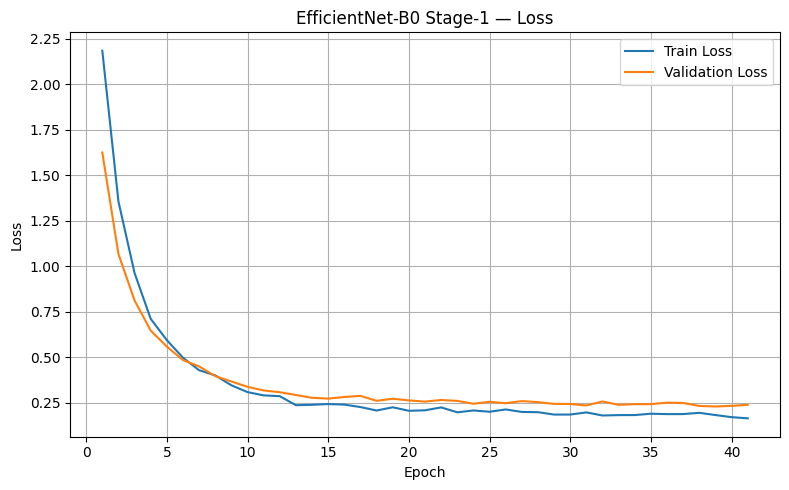

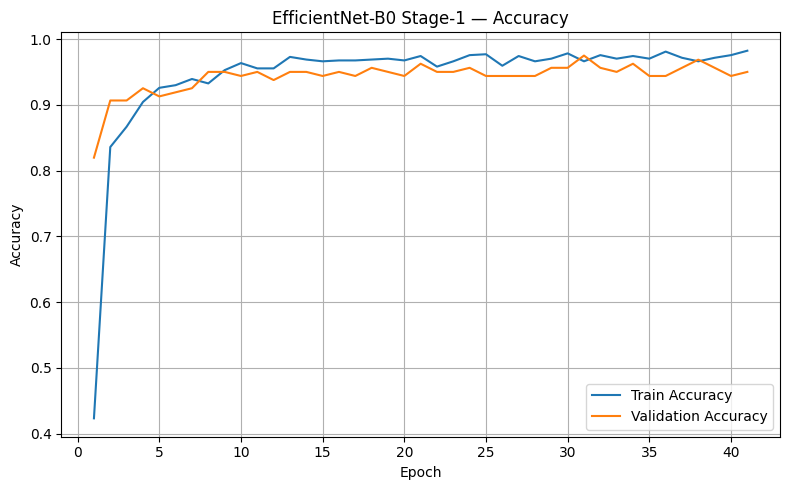

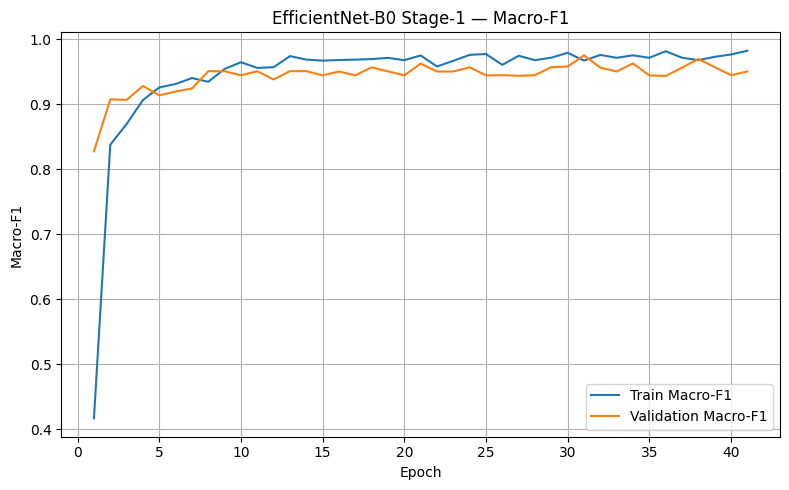

In [13]:
# LOSS

plt.figure(figsize=(8, 5))

plt.plot(
    history_frozen["epoch"],
    history_frozen["train_loss"],
    label="Train Loss"
)

plt.plot(
    history_frozen["epoch"],
    history_frozen["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNet-B0 Stage-1 — Loss")
plt.legend()
plt.grid()

plt.tight_layout()

plt.savefig(
    "/kaggle/working/"
    "efficientnet_b0_frozen_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ACCURACY

plt.figure(figsize=(8, 5))

plt.plot(
    history_frozen["epoch"],
    history_frozen["train_accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history_frozen["epoch"],
    history_frozen["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNet-B0 Stage-1 — Accuracy")
plt.legend()
plt.grid()

plt.tight_layout()

plt.savefig(
    "/kaggle/working/"
    "efficientnet_b0_frozen_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# MACRO-F1

plt.figure(figsize=(8, 5))

plt.plot(
    history_frozen["epoch"],
    history_frozen["train_macro_f1"],
    label="Train Macro-F1"
)

plt.plot(
    history_frozen["epoch"],
    history_frozen["val_macro_f1"],
    label="Validation Macro-F1"
)

plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.title("EfficientNet-B0 Stage-1 — Macro-F1")
plt.legend()
plt.grid()

plt.tight_layout()

plt.savefig(
    "/kaggle/working/"
    "efficientnet_b0_frozen_macro_f1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
FROZEN_CHECKPOINT = (
    "/kaggle/working/"
    "efficientnet_b0_frozen_best.pth"
)


checkpoint = torch.load(

    FROZEN_CHECKPOINT,

    map_location=DEVICE
)


model.load_state_dict(

    checkpoint[
        "model_state_dict"
    ]
)


print("=" * 70)
print("BEST STAGE-1 CHECKPOINT LOADED")
print("=" * 70)

print(
    "Best frozen epoch:",
    checkpoint["epoch"]
)

print(
    f"Frozen validation Macro-F1: "
    f"{checkpoint['val_macro_f1']*100:.2f}%"
)

BEST STAGE-1 CHECKPOINT LOADED
Best frozen epoch: 31
Frozen validation Macro-F1: 97.52%


In [15]:
# Freeze everything first

for param in model.parameters():

    param.requires_grad = False


# Unfreeze deeper EfficientNet blocks

for param in model.features[6].parameters():

    param.requires_grad = True


for param in model.features[7].parameters():

    param.requires_grad = True


for param in model.features[8].parameters():

    param.requires_grad = True


# Classifier

for param in model.classifier.parameters():

    param.requires_grad = True


model = model.to(DEVICE)


total_params = sum(

    p.numel()

    for p in model.parameters()
)


trainable_params = sum(

    p.numel()

    for p in model.parameters()

    if p.requires_grad
)


print("=" * 70)
print("FINE-TUNING PARAMETER CHECK")
print("=" * 70)

print(
    f"Total parameters     : "
    f"{total_params:,}"
)

print(
    f"Trainable parameters : "
    f"{trainable_params:,}"
)

print(
    f"Trainable percentage : "
    f"{100*trainable_params/total_params:.2f}%"
)


print("\n✅ Blocks 6, 7, 8 trainable.")
print("✅ Classifier trainable.")
print("✅ Earlier blocks frozen.")

FINE-TUNING PARAMETER CHECK
Total parameters     : 4,025,482
Trainable parameters : 3,173,674
Trainable percentage : 78.84%

✅ Blocks 6, 7, 8 trainable.
✅ Classifier trainable.
✅ Earlier blocks frozen.


In [16]:
criterion_ft = nn.CrossEntropyLoss()


optimizer_ft = optim.AdamW(

    [

        {
            "params":
                model.features[6].parameters(),

            "lr": 1e-5
        },

        {
            "params":
                model.features[7].parameters(),

            "lr": 1e-5
        },

        {
            "params":
                model.features[8].parameters(),

            "lr": 2e-5
        },

        {
            "params":
                model.classifier.parameters(),

            "lr": 1e-4
        }

    ],

    weight_decay=1e-4
)


scheduler_ft = optim.lr_scheduler.ReduceLROnPlateau(

    optimizer_ft,

    mode="max",

    factor=0.5,

    patience=3
)


print("=" * 70)
print("FINE-TUNING CONFIGURATION")
print("=" * 70)

print("Block 6 LR          : 1e-5")
print("Block 7 LR          : 1e-5")
print("Block 8 LR          : 2e-5")
print("Classifier LR       : 1e-4")
print("Weight decay        : 1e-4")
print("Scheduler patience  : 3")
print("Early-stop patience : 10")
print("Maximum epochs      : 100")

FINE-TUNING CONFIGURATION
Block 6 LR          : 1e-5
Block 7 LR          : 1e-5
Block 8 LR          : 2e-5
Classifier LR       : 1e-4
Weight decay        : 1e-4
Scheduler patience  : 3
Early-stop patience : 10
Maximum epochs      : 100


In [17]:
def run_epoch_finetune(
    model,
    loader,
    criterion,
    device,
    optimizer=None
):

    is_training = optimizer is not None


    if is_training:

        model.train()

        # Keep early frozen blocks fixed
        for i in range(6):

            model.features[i].eval()

    else:

        model.eval()


    running_loss = 0.0

    y_true = []
    y_pred = []


    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        if is_training:

            optimizer.zero_grad()


        with torch.set_grad_enabled(
            is_training
        ):

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )


            if is_training:

                loss.backward()

                optimizer.step()


        running_loss += (
            loss.item()
            *
            images.size(0)
        )


        predictions = torch.argmax(
            outputs,
            dim=1
        )


        y_true.extend(

            labels.detach()
            .cpu()
            .numpy()
        )


        y_pred.extend(

            predictions.detach()
            .cpu()
            .numpy()
        )


    epoch_loss = (
        running_loss
        /
        len(loader.dataset)
    )


    return {

        "loss":
            epoch_loss,

        "accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "precision":
            precision_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "recall":
            recall_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "macro_f1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            )
    }

In [18]:
def train_finetune(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    epochs=100,
    patience=10,
    save_path="/kaggle/working/efficientnet_b0_finetuned_best.pth"
):

    history = []

    best_f1 = -1.0
    best_epoch = 0
    no_improvement = 0

    best_weights = copy.deepcopy(
        model.state_dict()
    )


    for epoch in range(1, epochs + 1):

        start_time = time.time()


        train_metrics = run_epoch_finetune(

            model,
            train_loader,
            criterion,
            device,
            optimizer
        )


        val_metrics = run_epoch_finetune(

            model,
            val_loader,
            criterion,
            device,
            optimizer=None
        )


        current_lrs = [

            group["lr"]

            for group
            in optimizer.param_groups
        ]


        scheduler.step(
            val_metrics["macro_f1"]
        )


        elapsed = time.time() - start_time


        history.append({

            "epoch":
                epoch,

            "train_loss":
                train_metrics["loss"],

            "train_accuracy":
                train_metrics["accuracy"],

            "train_precision":
                train_metrics["precision"],

            "train_recall":
                train_metrics["recall"],

            "train_macro_f1":
                train_metrics["macro_f1"],

            "val_loss":
                val_metrics["loss"],

            "val_accuracy":
                val_metrics["accuracy"],

            "val_precision":
                val_metrics["precision"],

            "val_recall":
                val_metrics["recall"],

            "val_macro_f1":
                val_metrics["macro_f1"],

            "lr_block6":
                current_lrs[0],

            "lr_block7":
                current_lrs[1],

            "lr_block8":
                current_lrs[2],

            "lr_classifier":
                current_lrs[3],

            "epoch_time_sec":
                elapsed
        })


        print("\n" + "=" * 78)

        print(
            f"FINE-TUNE EPOCH "
            f"{epoch:03d}/{epochs}"
        )

        print("=" * 78)


        print(

            f"TRAIN | "
            f"Loss: {train_metrics['loss']:.4f} | "
            f"Acc: {train_metrics['accuracy']*100:.2f}% | "
            f"F1: {train_metrics['macro_f1']*100:.2f}%"
        )


        print(

            f"VAL   | "
            f"Loss: {val_metrics['loss']:.4f} | "
            f"Acc: {val_metrics['accuracy']*100:.2f}% | "
            f"Precision: {val_metrics['precision']*100:.2f}% | "
            f"Recall: {val_metrics['recall']*100:.2f}% | "
            f"F1: {val_metrics['macro_f1']*100:.2f}%"
        )


        print(
            "LRs:",
            [f"{lr:.2e}" for lr in current_lrs]
        )

        print(
            f"Time: {elapsed:.1f}s"
        )


        if val_metrics["macro_f1"] > best_f1:

            best_f1 = val_metrics["macro_f1"]

            best_epoch = epoch

            no_improvement = 0

            best_weights = copy.deepcopy(
                model.state_dict()
            )


            torch.save(

                {

                    "epoch":
                        best_epoch,

                    "model_state_dict":
                        best_weights,

                    "optimizer_state_dict":
                        optimizer.state_dict(),

                    "val_macro_f1":
                        best_f1,

                    "class_to_idx":
                        train_dataset.class_to_idx,

                    "seed":
                        SEED,

                    "img_size":
                        IMG_SIZE,

                    "batch_size":
                        BATCH_SIZE,

                    "architecture":
                        "EfficientNet-B0",

                    "training_stage":
                        "Fine-Tuned",

                    "fine_tuned_blocks":
                        [6, 7, 8]

                },

                save_path
            )


            print(
                "✅ NEW BEST FINE-TUNED CHECKPOINT SAVED"
            )


        else:

            no_improvement += 1

            print(
                f"No improvement: "
                f"{no_improvement}/{patience}"
            )


        if no_improvement >= patience:

            print(
                "\n⏹ FINE-TUNING EARLY STOPPING"
            )

            break


    model.load_state_dict(
        best_weights
    )


    history_df = pd.DataFrame(
        history
    )


    print("\n" + "=" * 78)
    print("FINE-TUNING COMPLETE")
    print("=" * 78)

    print(
        "Best fine-tuning epoch:",
        best_epoch
    )

    print(
        f"Best Validation Macro-F1: "
        f"{best_f1*100:.2f}%"
    )


    return model, history_df

In [19]:
model, history_ft = train_finetune(

    model=model,

    train_loader=train_loader,

    val_loader=val_loader,

    criterion=criterion_ft,

    optimizer=optimizer_ft,

    scheduler=scheduler_ft,

    device=DEVICE,

    epochs=100,

    patience=10,

    save_path=
    "/kaggle/working/efficientnet_b0_finetuned_best.pth"
)


FINE-TUNE EPOCH 001/100
TRAIN | Loss: 0.1632 | Acc: 97.58% | F1: 97.62%
VAL   | Loss: 0.1991 | Acc: 96.89% | Precision: 97.02% | Recall: 97.09% | F1: 97.00%
LRs: ['1.00e-05', '1.00e-05', '2.00e-05', '1.00e-04']
Time: 30.1s
✅ NEW BEST FINE-TUNED CHECKPOINT SAVED

FINE-TUNE EPOCH 002/100
TRAIN | Loss: 0.1502 | Acc: 98.39% | F1: 98.43%
VAL   | Loss: 0.1904 | Acc: 96.89% | Precision: 97.05% | Recall: 97.00% | F1: 96.94%
LRs: ['1.00e-05', '1.00e-05', '2.00e-05', '1.00e-04']
Time: 29.6s
No improvement: 1/10

FINE-TUNE EPOCH 003/100
TRAIN | Loss: 0.1358 | Acc: 97.85% | F1: 97.85%
VAL   | Loss: 0.1676 | Acc: 97.52% | Precision: 97.70% | Recall: 97.60% | F1: 97.59%
LRs: ['1.00e-05', '1.00e-05', '2.00e-05', '1.00e-04']
Time: 29.0s
✅ NEW BEST FINE-TUNED CHECKPOINT SAVED

FINE-TUNE EPOCH 004/100
TRAIN | Loss: 0.1312 | Acc: 98.39% | F1: 98.33%
VAL   | Loss: 0.1574 | Acc: 96.89% | Precision: 97.02% | Recall: 97.09% | F1: 97.00%
LRs: ['1.00e-05', '1.00e-05', '2.00e-05', '1.00e-04']
Time: 29.4s
No im

In [20]:
best_ft = history_ft.loc[

    history_ft[
        "val_macro_f1"
    ].idxmax()
]


print("=" * 75)
print("EFFICIENTNET-B0 FINE-TUNED RESULT")
print("=" * 75)


print(
    f"Best Epoch           : "
    f"{int(best_ft['epoch'])}"
)

print(
    f"Validation Accuracy  : "
    f"{best_ft['val_accuracy']*100:.2f}%"
)

print(
    f"Validation Precision : "
    f"{best_ft['val_precision']*100:.2f}%"
)

print(
    f"Validation Recall    : "
    f"{best_ft['val_recall']*100:.2f}%"
)

print(
    f"Validation Macro-F1  : "
    f"{best_ft['val_macro_f1']*100:.2f}%"
)

print(
    f"Validation Loss      : "
    f"{best_ft['val_loss']:.4f}"
)

EFFICIENTNET-B0 FINE-TUNED RESULT
Best Epoch           : 12
Validation Accuracy  : 97.52%
Validation Precision : 97.61%
Validation Recall    : 97.74%
Validation Macro-F1  : 97.65%
Validation Loss      : 0.1150


In [21]:
comparison = pd.DataFrame({

    "Experiment": [

        "EfficientNet-B0 Frozen",

        "EfficientNet-B0 Fine-Tuned"
    ],

    "Accuracy": [

        best_frozen["val_accuracy"],

        best_ft["val_accuracy"]
    ],

    "Precision": [

        best_frozen["val_precision"],

        best_ft["val_precision"]
    ],

    "Recall": [

        best_frozen["val_recall"],

        best_ft["val_recall"]
    ],

    "Macro-F1": [

        best_frozen["val_macro_f1"],

        best_ft["val_macro_f1"]
    ],

    "Loss": [

        best_frozen["val_loss"],

        best_ft["val_loss"]
    ]

})


comparison

,Experiment,Accuracy,Precision,Recall,Macro-F1,Loss
0,EfficientNet-B0 Frozen,0.975155,0.977839,0.975108,0.975172,0.234948
1,EfficientNet-B0 Fine-Tuned,0.975155,0.976107,0.977350,0.976512,0.115012


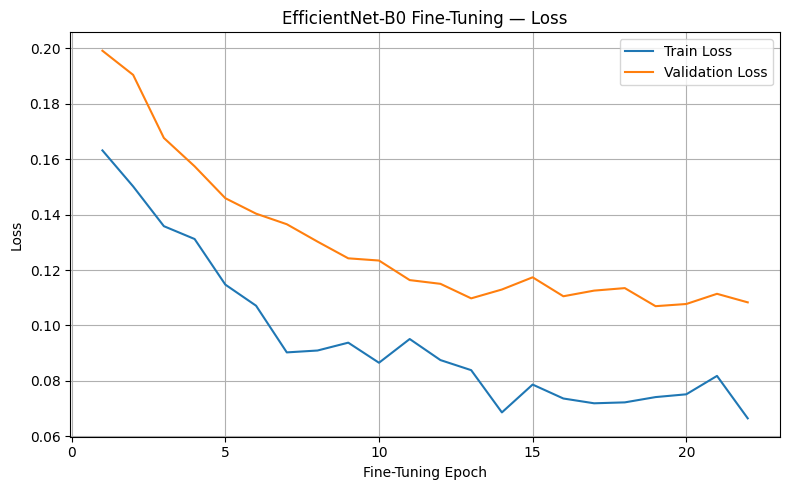

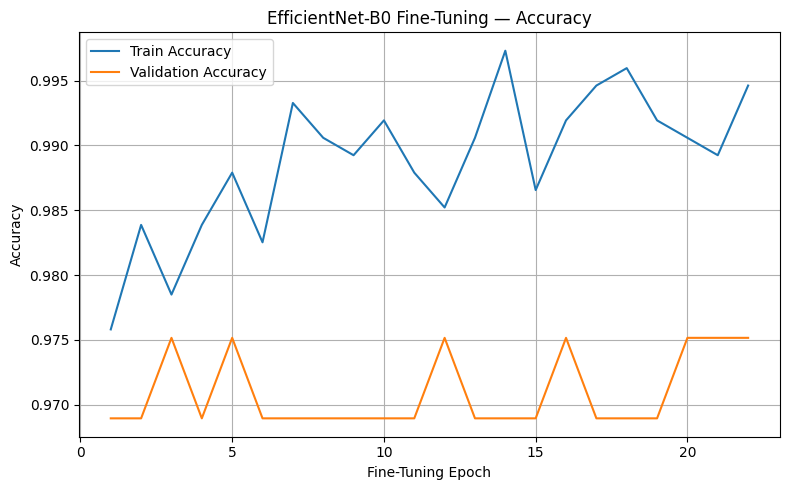

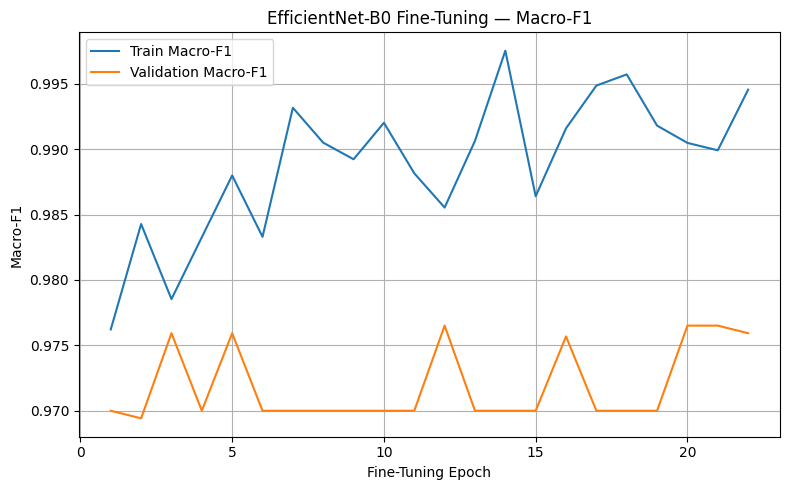

In [22]:
# LOSS

plt.figure(figsize=(8, 5))

plt.plot(
    history_ft["epoch"],
    history_ft["train_loss"],
    label="Train Loss"
)

plt.plot(
    history_ft["epoch"],
    history_ft["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Fine-Tuning Epoch")
plt.ylabel("Loss")
plt.title("EfficientNet-B0 Fine-Tuning — Loss")
plt.legend()
plt.grid()

plt.tight_layout()

plt.savefig(
    "/kaggle/working/"
    "efficientnet_b0_finetune_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ACCURACY

plt.figure(figsize=(8, 5))

plt.plot(
    history_ft["epoch"],
    history_ft["train_accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history_ft["epoch"],
    history_ft["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Fine-Tuning Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNet-B0 Fine-Tuning — Accuracy")
plt.legend()
plt.grid()

plt.tight_layout()

plt.savefig(
    "/kaggle/working/"
    "efficientnet_b0_finetune_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# MACRO-F1

plt.figure(figsize=(8, 5))

plt.plot(
    history_ft["epoch"],
    history_ft["train_macro_f1"],
    label="Train Macro-F1"
)

plt.plot(
    history_ft["epoch"],
    history_ft["val_macro_f1"],
    label="Validation Macro-F1"
)

plt.xlabel("Fine-Tuning Epoch")
plt.ylabel("Macro-F1")
plt.title(
    "EfficientNet-B0 Fine-Tuning — Macro-F1"
)

plt.legend()
plt.grid()

plt.tight_layout()

plt.savefig(
    "/kaggle/working/"
    "efficientnet_b0_finetune_macro_f1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
history_ft.to_csv(

    "/kaggle/working/"
    "efficientnet_b0_finetune_history.csv",

    index=False
)


comparison.to_csv(

    "/kaggle/working/"
    "efficientnet_b0_frozen_vs_finetuned.csv",

    index=False
)


print("✅ Frozen history saved.")
print("✅ Fine-tuning history saved.")
print("✅ Comparison CSV saved.")

✅ Frozen history saved.
✅ Fine-tuning history saved.
✅ Comparison CSV saved.


In [24]:
important_files = [

    "/kaggle/working/"
    "efficientnet_b0_frozen_best.pth",

    "/kaggle/working/"
    "efficientnet_b0_finetuned_best.pth"
]


print("=" * 75)
print("CHECKPOINT VERIFICATION")
print("=" * 75)


for path in important_files:

    exists = os.path.exists(path)

    print(
        os.path.basename(path),
        "->",
        exists
    )

    if exists:

        print(
            f"Size: "
            f"{os.path.getsize(path)/(1024**2):.2f} MB"
        )


assert all(
    os.path.exists(path)
    for path in important_files
)


print(
    "\n✅ BOTH CRITICAL CHECKPOINTS ARE SAFE."
)

CHECKPOINT VERIFICATION
efficientnet_b0_frozen_best.pth -> True
Size: 15.79 MB
efficientnet_b0_finetuned_best.pth -> True
Size: 39.92 MB

✅ BOTH CRITICAL CHECKPOINTS ARE SAFE.


In [25]:
files_to_backup = [

    "efficientnet_b0_frozen_best.pth",

    "efficientnet_b0_finetuned_best.pth",

    "efficientnet_b0_frozen_history.csv",

    "efficientnet_b0_finetune_history.csv",

    "efficientnet_b0_frozen_vs_finetuned.csv",

    "efficientnet_b0_frozen_loss.png",

    "efficientnet_b0_frozen_accuracy.png",

    "efficientnet_b0_frozen_macro_f1.png",

    "efficientnet_b0_finetune_loss.png",

    "efficientnet_b0_finetune_accuracy.png",

    "efficientnet_b0_finetune_macro_f1.png"
]


zip_path = (

    "/kaggle/working/"
    "EfficientNetB0_Complete_Artifacts.zip"
)


with zipfile.ZipFile(

    zip_path,

    "w",

    zipfile.ZIP_DEFLATED

) as z:

    for filename in files_to_backup:

        full_path = os.path.join(
            "/kaggle/working",
            filename
        )

        if os.path.exists(full_path):

            z.write(
                full_path,
                arcname=filename
            )


print("=" * 75)
print("FINAL BACKUP")
print("=" * 75)

print(
    "ZIP:",
    zip_path
)

print(
    f"Size: "
    f"{os.path.getsize(zip_path)/(1024**2):.2f} MB"
)

print(
    "\n✅ Download this ZIP before closing Kaggle."
)

FINAL BACKUP
ZIP: /kaggle/working/EfficientNetB0_Complete_Artifacts.zip
Size: 51.96 MB

✅ Download this ZIP before closing Kaggle.
